<a href="https://colab.research.google.com/github/guupiii/ESAA/blob/main/eda1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [128]:
import pandas as pd
import numpy as np

In [129]:
df = pd.read_csv('/content/drive/MyDrive/MLData/insurance.csv')

In [130]:
df = df.drop(columns=['region'])

In [131]:
df.head()

,age,sex,bmi,children,smoker,charges
0,19,female,27.900,0,yes,16884.92400
1,18,male,33.770,1,no,1725.55230
2,28,male,33.000,3,no,4449.46200
3,33,male,22.705,0,no,21984.47061
4,32,male,28.880,0,no,3866.85520


In [132]:
df['charges'] = np.log1p(df['charges'])

In [ ]:
df['charges'].head()

,charges
0,9.734236
1,7.453882
2,8.400763
3,9.998137
4,8.260455


In [133]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
df.head()

,age,bmi,children,charges,sex_male,smoker_yes
0,19,27.900,0,9.734236,False,True
1,18,33.770,1,7.453882,True,False
2,28,33.000,3,8.400763,True,False
3,33,22.705,0,9.998137,True,False
4,32,28.880,0,8.260455,True,False


In [134]:
from sklearn.model_selection import train_test_split

X = df.drop('charges', axis=1)
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# **1. Gradient Boosting**

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

gbr = GradientBoostingRegressor(random_state=42)

gbr.fit(X_train, y_train)

y_pred_gbr = gbr.predict(X_test)

mse_gbr = mean_squared_error(y_test, y_pred_gbr)
print("Gradient Boosting MSE:", mse_gbr)

Gradient Boosting MSE: 0.12336581866054602


In [ ]:
import numpy as np

rmse = np.sqrt(mean_squared_error(np.exp(y_test), np.exp(y_pred_gbr)))
print("RMSE:", rmse)

RMSE: 4387.8331662778955


# **2. XGBoost**

In [135]:
from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=42)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [136]:
import numpy as np
from sklearn.metrics import mean_squared_error

rmse_xgb = np.sqrt(
    mean_squared_error(
        np.exp(y_test),
        np.exp(y_pred_xgb)
    )
)

print("XGBoost RMSE:", rmse_xgb)

XGBoost RMSE: 5228.338425277588


In [137]:
print("Gradient Boosting RMSE:", rmse)
print("XGBoost RMSE:", rmse_xgb)

Gradient Boosting RMSE: 4354.073743148385
XGBoost RMSE: 5228.338425277588


* RandomizedSearchCV


XGBoost

In [215]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=42)

param_dist = {
    'n_estimators': [700, 900, 1100],
    'learning_rate': [0.01, 0.015, 0.02],
    'max_depth': [2, 3],
    'subsample': [0.75, 0.8, 0.85],
    'colsample_bytree': [0.75, 0.8, 0.85],
    'reg_alpha': [0, 0.05, 0.1],
    'reg_lambda': [2, 3, 4]
}

random_search = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist,
    n_iter=30,
    scoring='neg_root_mean_squared_error',
    cv=3,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train,)

RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.75, 0.8, 0.85],
                                        'learning_rate': [0.01, 0.015, 0.02],
                                        'max_depth': [2, 3],
                                        'n_estimators': [700, 900, 1100],
                                        'reg_alpha': [0, 0.05, 0.1],
                                        'reg_lambda': [2, 3, 4],
                                        'subsample': [0.75, 0.8, 0.85]},
                   random_state=42, scoring='neg_root_mean_squared_error')

In [216]:
print(random_search.best_params_)

{'subsample': 0.75, 'reg_lambda': 2, 'reg_alpha': 0.05, 'n_estimators': 700, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.8}


In [217]:
best_xgb = random_search.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)

In [218]:
import numpy as np
from sklearn.metrics import mean_squared_error

rmse_xgb = np.sqrt(
    mean_squared_error(
        np.exp(y_test),
        np.exp(y_pred_xgb)
    )
)

print("튜닝된 XGBoost RMSE:", rmse_xgb)

튜닝된 XGBoost RMSE: 4282.552022700455


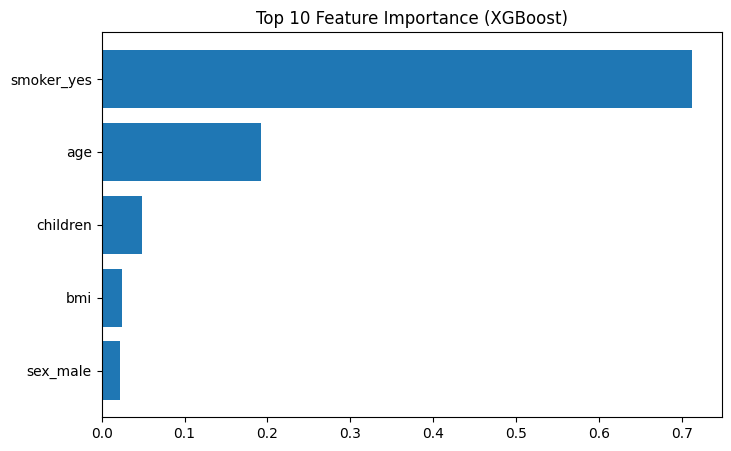

In [143]:
import matplotlib.pyplot as plt
import pandas as pd

importance = best_xgb.feature_importances_
features = X_train.columns

imp_df = pd.DataFrame({
    'feature': features,
    'importance': importance
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(8,5))
plt.barh(imp_df['feature'][:10], imp_df['importance'][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importance (XGBoost)")
plt.show()

+) GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [600, 700, 800],
    'learning_rate': [0.008, 0.01, 0.012],
    'max_depth': [2, 3],
    'subsample': [0.7, 0.75, 0.8],
    'colsample_bytree': [0.75, 0.8, 0.85],
    'reg_alpha': [0.03, 0.05, 0.07],
    'reg_lambda': [1.5, 2, 2.5]
}

grid_search = GridSearchCV(
    XGBRegressor(random_state=42),
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None...
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.75, 0.8, 0.85],
                         'learning_rate': [0.008, 0.01, 0.012],
                         'max_depth': [2, 3], 'n_estimators': [600, 700, 800],
                         'reg_alpha': [0.03, 0.05, 0.07],
                         'reg_lambda': [1.5, 2, 2.5],
                         'subsample': [0.7, 0.75, 0.8]},
             scoring='neg_mean_squared_error')

In [ ]:
best_xgb = grid_search.best_estimator_
y_pred = best_xgb.predict(X_test)

rmse = np.sqrt(mean_squared_error(np.exp(y_test), np.exp(y_pred)))
print("최종 RMSE:", rmse)
print("Best params:", grid_search.best_params_)

최종 RMSE: 4354.073743148385
Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.008, 'max_depth': 3, 'n_estimators': 600, 'reg_alpha': 0.07, 'reg_lambda': 2.5, 'subsample': 0.7}


**Gradient Boosting**

In [219]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(random_state=42)

param_dist_gbr = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [2, 3, 4],
    'subsample': [0.8, 1.0]
}

random_search_gbr = RandomizedSearchCV(
    gbr,
    param_distributions=param_dist_gbr,
    n_iter=10,
    scoring='neg_root_mean_squared_error',
    cv=3,
    random_state=42,
    n_jobs=-1
)

random_search_gbr.fit(X_train, y_train)

best_gbr = random_search_gbr.best_estimator_

In [221]:
y_pred_gbr = best_gbr.predict(X_test)

rmse_gbr = np.sqrt(
    mean_squared_error(
        np.exp(y_test),
        np.exp(y_pred_gbr)
    )
)

print("Gradient Boosting RMSE:", rmse_gbr)

Gradient Boosting RMSE: 4505.9728691027885


* 최저 RMSE



XGBoost : 4282.552022700455

Gradient Boosting : 4387.8331662778955